<a href="https://colab.research.google.com/github/Ajwad07/ML_projects_/blob/main/AER_UNet_WaterBody_Segmentation_edited.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  AER U-Net: Water Body Segmentation with Attention and Residual Blocks
This notebook replicates the AER U-Net architecture for segmenting water bodies using Sentinel-2 satellite images, as described in the paper.

In [1]:
# ✅ Install dependencies
!pip install gdown wget > /dev/null

In [2]:
# ✅ Download and unzip dataset using gdown
import gdown, zipfile, os

dataset_id = "1wkT49udNvNw5uqiekhMN5ZjuaECR92lw"
zip_path = "RMAS_dataset.zip"
extract_dir = "RMAS_dataset"

print("Downloading dataset using gdown...")
gdown.download(id=dataset_id, output=zip_path, quiet=False)

print("\nUnzipping...")
try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Unzipping complete.")
    if os.path.exists(extract_dir):
        os.remove(zip_path)
        print(f"Removed {zip_path}")
except Exception as e:
    print(f"Error during unzipping: {e}")

Downloading...
From (original): https://drive.google.com/uc?id=1wkT49udNvNw5uqiekhMN5ZjuaECR92lw
From (redirected): https://drive.google.com/uc?id=1wkT49udNvNw5uqiekhMN5ZjuaECR92lw&confirm=t&uuid=8d5bf433-7799-410c-8877-b4a6e4a57709
To: /content/RMAS_dataset.zip
100%|██████████| 522M/522M [00:07<00:00, 71.4MB/s]



Unzipping...
Unzipping complete.
Removed RMAS_dataset.zip


##  Define AER U-Net Components

In [3]:
# Convolution Block
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

In [4]:
# Residual Block
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = ConvBlock(in_channels, out_channels)
        self.drop = nn.Dropout(0.3)
        self.conv2 = ConvBlock(out_channels, out_channels)
        self.residual = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        identity = self.residual(x)
        out = self.conv1(x)
        out = self.drop(out)
        out = self.conv2(out)
        return out + identity

In [5]:
# Attention Block
class AttentionBlock(nn.Module):
    def __init__(self, g_ch, x_ch):
        super().__init__()
        self.W_g = nn.Conv2d(g_ch, x_ch, kernel_size=1)
        self.W_x = nn.Conv2d(x_ch, x_ch, kernel_size=1)
        self.psi = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv2d(x_ch, 1, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.psi(g1 + x1)
        return x * psi

In [6]:
# AER U-Net Model
class AER_UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = ResidualBlock(3, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ResidualBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ResidualBlock(64, 128)
        self.pool3 = nn.MaxPool2d(2)
        self.bottleneck = ResidualBlock(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.att3 = AttentionBlock(128, 128)
        self.dec3 = ResidualBlock(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.att2 = AttentionBlock(64, 64)
        self.dec2 = ResidualBlock(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.att1 = AttentionBlock(32, 32)
        self.dec1 = ResidualBlock(64, 32)

        self.final = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        e3 = self.att3(d3, e3)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        e2 = self.att2(d2, e2)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        e1 = self.att1(d1, e1)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return torch.sigmoid(self.final(d1))

**bold text**##  Preprocess and Load RMAS Dataset

In [7]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

class WaterBodyDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.image_dir, self.images[idx])).convert("RGB")
        mask = Image.open(os.path.join(self.mask_dir, self.images[idx])).convert("L")
        if self.transform:
            img = self.transform(img)
            mask = self.transform(mask)
        return img, mask

In [8]:
# Load training and test sets
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

train_set = WaterBodyDataset("/content/RMAS_dataset/train/img", "/content/RMAS_dataset/train/label", transform)
test_set = WaterBodyDataset("/content/RMAS_dataset/test/img", "/content/RMAS_dataset/test/label", transform)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1)

##  Train the AER U-Net

In [10]:
import torch.optim as optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AER_UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

for epoch in range(30):
    model.train()
    total_loss = 0
    for img, mask in tqdm(train_loader):
        img, mask = img.to(device), mask.to(device)
        pred = model(img)
        loss = criterion(pred, mask)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

100%|██████████| 315/315 [01:47<00:00,  2.94it/s]


Epoch 1, Loss: 0.2698


100%|██████████| 315/315 [01:44<00:00,  3.02it/s]


Epoch 2, Loss: 0.2452


100%|██████████| 315/315 [01:45<00:00,  2.99it/s]


...

Epoch 28, Loss: 0.1349


100%|██████████| 315/315 [01:44<00:00,  3.02it/s]


Epoch 29, Loss: 0.1308


100%|██████████| 315/315 [01:43<00:00,  3.03it/s]

Epoch 30, Loss: 0.1261


In [12]:
dummy = torch.randn(1, 3, 128, 128)
out = model(dummy)
print(out.shape)  # Should be (1, 1, 128, 128)

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument weight in method wrapper_CUDA___slow_conv2d_forward)

##  Evaluate AER U-Net with IoU, Dice, F1, Precision, Recall

In [13]:
def compute_metrics(pred, mask):
    pred = (pred > 0.5).astype(np.uint8)
    mask = (mask > 0.5).astype(np.uint8)
    TP = np.logical_and(pred == 1, mask == 1).sum()
    TN = np.logical_and(pred == 0, mask == 0).sum()
    FP = np.logical_and(pred == 1, mask == 0).sum()
    FN = np.logical_and(pred == 0, mask == 1).sum()
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    iou = TP / (TP + FP + FN + 1e-8)
    dice = 2 * TP / (2 * TP + FP + FN + 1e-8)
    acc = (TP + TN) / (TP + TN + FP + FN + 1e-8)
    return precision, recall, f1, iou, dice, acc

In [14]:
model.eval()
scores = []
with torch.no_grad():
    for img, mask in tqdm(test_loader):
        img = img.to(device)
        pred = model(img).cpu().squeeze().numpy()
        mask = mask.squeeze().numpy()
        scores.append(compute_metrics(pred, mask))

scores = np.array(scores)
print(f"Precision: {scores[:,0].mean():.4f}, Recall: {scores[:,1].mean():.4f}, F1: {scores[:,2].mean():.4f}, ")
print(f"IoU: {scores[:,3].mean():.4f}, Dice: {scores[:,4].mean():.4f}, Accuracy: {scores[:,5].mean():.4f}")

100%|██████████| 500/500 [00:13<00:00, 36.60it/s]

Precision: 0.6296, Recall: 0.4295, F1: 0.4568, 
IoU: 0.3471, Dice: 0.4568, Accuracy: 0.9374


##  Visualize Predictions

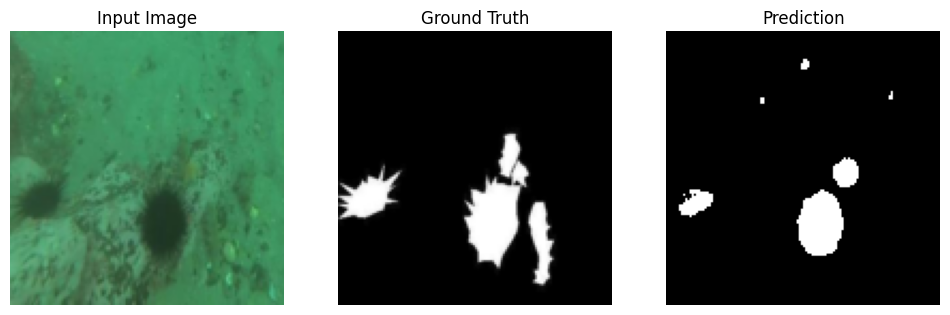

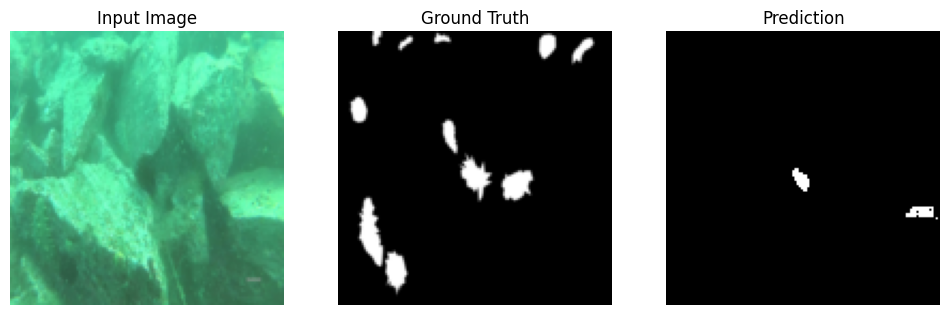

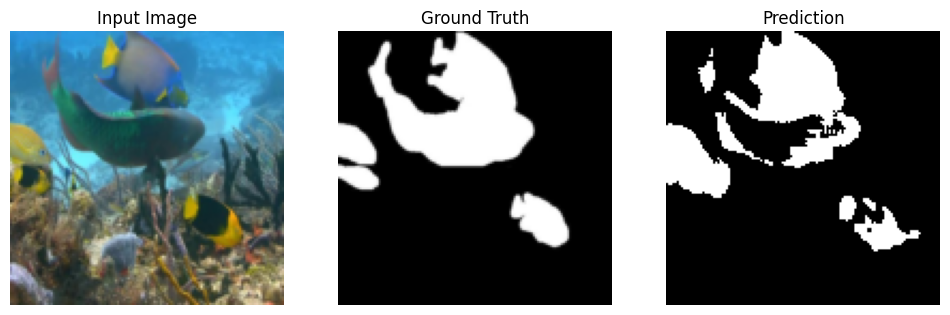

In [15]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    for idx, (img, mask) in enumerate(test_loader):
        img = img.to(device)
        pred = model(img).cpu().squeeze().numpy()
        img = img.cpu().squeeze().permute(1, 2, 0).numpy()
        mask = mask.squeeze().numpy()

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(img)
        plt.title("Input Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(mask, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pred > 0.5, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")
        plt.show()

        if idx == 2:
            break  # Show only first 3 samples

In [16]:
# Install torchinfo
!pip install torchinfo > /dev/null

In [17]:
from torchinfo import summary

summary(model, input_size=(1, 3, 128, 128))

Layer (type:depth-idx)                   Output Shape              Param #
AER_UNet                                 [1, 1, 128, 128]          --
├─ResidualBlock: 1-1                     [1, 32, 128, 128]         --
│    └─Conv2d: 2-1                       [1, 32, 128, 128]         128
│    └─ConvBlock: 2-2                    [1, 32, 128, 128]         --
│    │    └─Sequential: 3-1              [1, 32, 128, 128]         960
│    └─Dropout: 2-3                      [1, 32, 128, 128]         --
│    └─ConvBlock: 2-4                    [1, 32, 128, 128]         --
│    │    └─Sequential: 3-2              [1, 32, 128, 128]         9,312
├─MaxPool2d: 1-2                         [1, 32, 64, 64]           --
├─ResidualBlock: 1-3                     [1, 64, 64, 64]           --
│    └─Conv2d: 2-5                       [1, 64, 64, 64]           2,112
│    └─ConvBlock: 2-6                    [1, 64, 64, 64]           --
│    │    └─Sequential: 3-3              [1, 64, 64, 64]           18,624
│  


Training Vanilla U-Net...


100%|██████████| 315/315 [01:34<00:00,  3.33it/s]


Epoch 1, Loss: 0.3087


100%|██████████| 315/315 [01:30<00:00,  3.49it/s]


Epoch 2, Loss: 0.2476


...

Epoch 29, Loss: 0.1526


100%|██████████| 315/315 [01:29<00:00,  3.50it/s]


Epoch 30, Loss: 0.1494


100%|██████████| 500/500 [00:11<00:00, 41.77it/s]



Vanilla U-Net Evaluation:
Precision: 0.6180, Recall: 0.3432, F1: 0.3881, 
IoU: 0.2868, Dice: 0.3881, Accuracy: 0.9310

Visualizing Vanilla U-Net predictions:


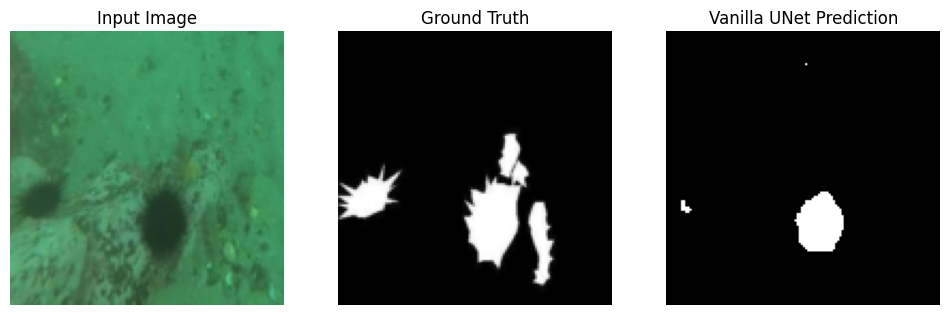

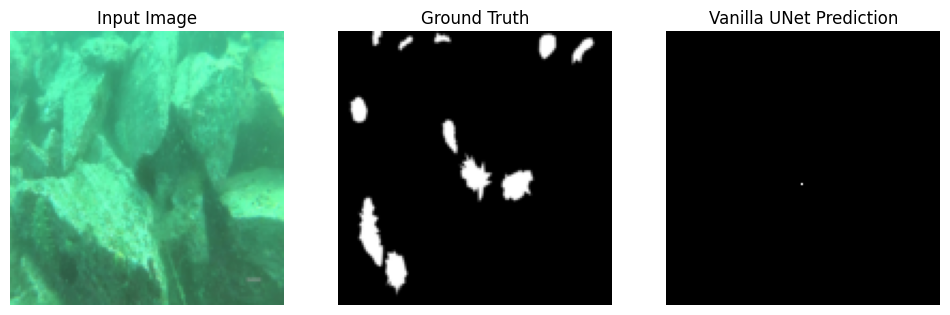

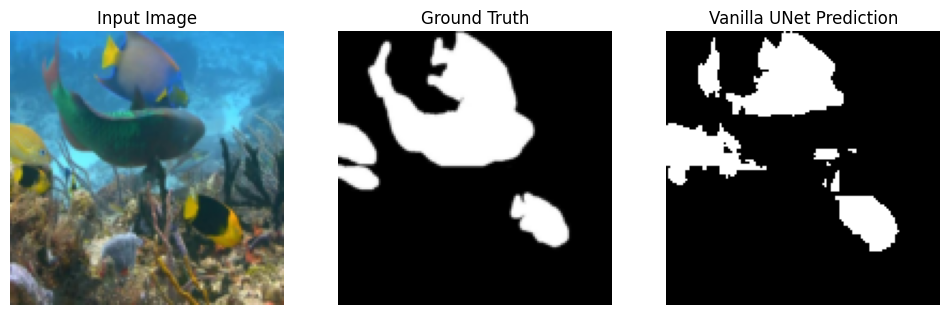

Layer (type:depth-idx)                   Output Shape              Param #
VanillaUNet                              [1, 1, 128, 128]          --
├─ConvBlock: 1-1                         [1, 32, 128, 128]         --
│    └─Sequential: 2-1                   [1, 32, 128, 128]         --
│    │    └─Conv2d: 3-1                  [1, 32, 128, 128]         896
│    │    └─BatchNorm2d: 3-2             [1, 32, 128, 128]         64
│    │    └─ReLU: 3-3                    [1, 32, 128, 128]         --
├─MaxPool2d: 1-2                         [1, 32, 64, 64]           --
├─ConvBlock: 1-3                         [1, 64, 64, 64]           --
│    └─Sequential: 2-2                   [1, 64, 64, 64]           --
│    │    └─Conv2d: 3-4                  [1, 64, 64, 64]           18,496
│    │    └─BatchNorm2d: 3-5             [1, 64, 64, 64]           128
│    │    └─ReLU: 3-6                    [1, 64, 64, 64]           --
├─MaxPool2d: 1-4                         [1, 64, 32, 32]           --
├─ConvBlo

In [18]:


import matplotlib.pyplot as plt
import numpy as np
# Basic Vanilla U-Net Model
class VanillaUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = ConvBlock(3, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(64, 128)
        self.pool3 = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(64, 32)

        self.final = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        # Vanilla U-Net concatenation
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        # Vanilla U-Net concatenation
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        # Vanilla U-Net concatenation
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return torch.sigmoid(self.final(d1))

# Instantiate and train the Vanilla U-Net
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vanilla_model = VanillaUNet().to(device)
optimizer = optim.Adam(vanilla_model.parameters(), lr=0.001)
criterion = nn.BCELoss()

print("\nTraining Vanilla U-Net...")
for epoch in range(30):
    vanilla_model.train()
    total_loss = 0
    for img, mask in tqdm(train_loader):
        img, mask = img.to(device), mask.to(device)
        pred = vanilla_model(img)
        loss = criterion(pred, mask)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

# Evaluate Vanilla U-Net
vanilla_model.eval()
vanilla_scores = []
with torch.no_grad():
    for img, mask in tqdm(test_loader):
        img = img.to(device)
        pred = vanilla_model(img).cpu().squeeze().numpy()
        mask = mask.squeeze().numpy()
        vanilla_scores.append(compute_metrics(pred, mask))

vanilla_scores = np.array(vanilla_scores)
print("\nVanilla U-Net Evaluation:")
print(f"Precision: {vanilla_scores[:,0].mean():.4f}, Recall: {vanilla_scores[:,1].mean():.4f}, F1: {vanilla_scores[:,2].mean():.4f}, ")
print(f"IoU: {vanilla_scores[:,3].mean():.4f}, Dice: {vanilla_scores[:,4].mean():.4f}, Accuracy: {vanilla_scores[:,5].mean():.4f}")

# Visualize predictions from Vanilla U-Net
print("\nVisualizing Vanilla U-Net predictions:")
vanilla_model.eval()
with torch.no_grad():
    for idx, (img, mask) in enumerate(test_loader):
        img = img.to(device)
        pred = vanilla_model(img).cpu().squeeze().numpy()
        img_display = img.cpu().squeeze().permute(1, 2, 0).numpy()
        mask_display = mask.squeeze().numpy()

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(img_display)
        plt.title("Input Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(mask_display, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pred > 0.5, cmap="gray")
        plt.title("Vanilla UNet Prediction")
        plt.axis("off")
        plt.show()

        if idx == 2:
            break  # Show only first 3 samples

# Summary of Vanilla U-Net
summary(vanilla_model, input_size=(1, 3, 128, 128))


In [22]:
import pandas as pd

# Evaluation metrics from the previous outputs
aer_unet_metrics = {
    "Precision": 0.6296,
    "Recall": 0.4295,
    "F1": 0.4568,
    "IoU": 0.3471,
    "Dice": 0.4568,
    "Accuracy": 0.9374
}

vanilla_unet_metrics = {
    "Precision": 0.6180,
    "Recall": 0.3432,
    "F1": 0.3881,
    "IoU": 0.2868,
    "Dice": 0.3881,
    "Accuracy": 0.9310
}

# Create a pandas DataFrame for comparison
comparison_df = pd.DataFrame({
    "AER U-Net": aer_unet_metrics,
    "Vanilla U-Net": vanilla_unet_metrics
})

# Transpose the DataFrame for better readability
comparison_df = comparison_df.T

print("Comparison of Evaluation Metrics:")
display(comparison_df)

Comparison of Evaluation Metrics:


,Precision,Recall,F1,IoU,Dice,Accuracy
AER U-Net,0.6296,0.4295,0.4568,0.3471,0.4568,0.9374
Vanilla U-Net,0.6180,0.3432,0.3881,0.2868,0.3881,0.9310
